# Wheel motion trace — D / T / RT + a complex MOVE sequence

Drive the robot through the three single-segment verbs — **D** (distance),
**T** (timed), **RT** (relative in-place turn) — and then a **complex
5-segment `MOVE` sequence** (forward → turn right → forward → turn left →
back up), streaming the wheels' motion back over USB, and chart each wheel's
**position, speed, and acceleration** vs time.

**Robot on the stand, wheels off the ground** — safe to spin freely
(`.claude/rules/hardware-bench-testing.md`).

## How it works (post-094 gutted firmware)

The current firmware has **no `STREAM` / `EVT done` / `cmd=` / watchdog** — its
only telemetry is the one-shot **`TLM`** verb:

```
OK tlm enc=<L>,<R> vel=<L>,<R> active=<0|1> conn=<L>,<R>
```

So Python owns the loop: fire the motion command(s), then **poll `TLM` as fast
as the link allows**, host-timestamping each reply, until the executor reports
**`active=0`** — idle, i.e. the segment (or the whole queued sequence) has
finished and done its graceful decel-to-zero. `conn=1,1` confirms the Nezha
brick is on the I2C bus the whole time.

| chart | source | unit |
|---|---|---|
| **position** | `enc` − baseline (signed cumulative encoder travel) | mm |
| **speed** | `vel` — measured wheel velocity (signed) | mm/s |
| **acceleration** | *derived* — d(smoothed `vel`)/dt over host time | mm/s² |

The complex sequence is sent as five `MOVE` segments **queued back-to-back**
on `bb.segmentIn`; the drivetrain executes them head-to-tail (Ruckig
re-planning across the boundaries) and **auto-stops** when the queue drains.

## Running it

1. Robot on the stand, powered, USB connected. **Close any serial monitor on
   the port** — the notebook needs exclusive access. Confirm the port below.
2. Run all cells top-to-bottom. Each run caches to `out/wheel_trace_*.csv`;
   re-running the plot cell reads the cache (no hardware). Delete a CSV (or set
   `FORCE_RECAPTURE = True`) to re-drive that run.
3. The capture cell sends `STOP` in a `finally` block — motors are never left
   running (and every segment self-terminates anyway).

In [1]:
import pathlib
import re
import sys
import threading
import time

import numpy as np
import pandas as pd

# --- Paths: anchored to the repo, never CWD-relative. ---
_here = pathlib.Path.cwd()
REPO = next((p for p in [_here, *_here.parents]
             if (p / "host" / "robot_radio").is_dir()), None)
if REPO is None:
    REPO = pathlib.Path("/Volumes/Proj/proj/RobotProjects/radio-robot-elite")
sys.path.insert(0, str(REPO / "host"))

OUT_DIR = REPO / "tests" / "notebooks" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

from robot_radio.io.serial_conn import SerialConnection   # noqa: E402

# --- Session configuration -------------------------------------------------
PORT = "/dev/cu.usbmodem2121102"   # bench robot; check `ls /dev/cu.usbmodem*`
MODE = "direct"                    # direct USB link to the robot
POLL_MS = 15                       # [ms] TLM poll cadence during a run
SETTLE_S = 1.5                     # [s] idle (active=0) dwell that marks "done"
FORCE_RECAPTURE = False            # True re-drives even if cached

# The full TLM line (firmware v0.20260709.12+):
#   enc=  per-wheel encoder travel [mm] (0.1 resolution)
#   vel=  measured per-wheel velocity [mm/s] (0.1 resolution)
#   cmd=  post-governor COMMANDED per-wheel velocity [mm/s] (PID setpoint)
#   acc=  measured per-wheel acceleration, EMA-filtered IN FIRMWARE [mm/s^2]
#   active= busy flag; conn= per-motor I2C health; glitch= source-rejected
#   corrupt reads; ts= EACH WHEEL'S OWN SAMPLE INSTANT (firmware ms);
#   now=  the loop-pass instant this snapshot (incl. cmd=) was COMMITTED.
# The flip-flop samples the two wheels on different slots and USB-CDC
# batches/jitters reply delivery -- ts=/now= let this notebook plot every
# reading at its TRUE time instead of poll-receive time (which renders
# staircases on measured channels and kinks on the commanded ramp).
TLM_RE = re.compile(
    r"enc=(?P<enc_l>-?\d+\.\d),(?P<enc_r>-?\d+\.\d)"
    r" vel=(?P<vel_l>-?\d+\.\d),(?P<vel_r>-?\d+\.\d)"
    r" cmd=(?P<cmd_l>-?\d+),(?P<cmd_r>-?\d+)"
    r" acc=(?P<acc_l>-?\d+),(?P<acc_r>-?\d+)"
    r" active=(?P<active>[01])"
    r" conn=(?P<conn_l>[01]),(?P<conn_r>[01])"
    r" glitch=(?P<glitch_l>\d+),(?P<glitch_r>\d+)"
    r" ts=(?P<ts_l>\d+),(?P<ts_r>\d+)"
    r" now=(?P<now>\d+)")
TLM_FIELDS = ["enc_l", "enc_r", "vel_l", "vel_r", "cmd_l", "cmd_r",
              "acc_l", "acc_r", "active", "conn_l", "conn_r",
              "glitch_l", "glitch_r", "ts_l", "ts_r", "now"]

# The three single-segment cases + the complex sequence. Each run is a LIST of
# commands fired back-to-back: one for the singles, five for the sequence
# (which queue on bb.segmentIn and execute head-to-tail, then auto-stop).
#   D <vL> <vR> <mm>   -> straight, distance-bounded segment
#   T <vL> <vR> <ms>   -> straight, distance = v*t
#   RT <cdeg>          -> pure in-place relative turn (CCW+)
#   MOVE <mm> <dir_cdeg> <finalHeading_cdeg>  -> the full segment verb
RUNS = [
    {"label": "D",  "commands": ["D 200 200 400"],  "timeout": 8.0},
    {"label": "T",  "commands": ["T 200 200 1500"], "timeout": 8.0},
    {"label": "RT", "commands": ["RT 9000"],        "timeout": 10.0},
    {"label": "SEQUENCE", "timeout": 30.0, "commands": [
        "MOVE 300 0 0",     # 1. move forward
        "MOVE 0 0 -9000",   # 2. turn right  (CW  -> negative centidegrees)
        "MOVE 300 0 0",     # 3. move forward
        "MOVE 0 0 9000",    # 4. turn left   (CCW -> positive centidegrees)
        "MOVE -300 0 0",    # 5. back up
    ]},
]
print(f"repo:  {REPO}")
print(f"cache: {OUT_DIR}")
print(f"port:  {PORT}  (mode={MODE})")

repo:  /Volumes/Proj/proj/RobotProjects/radio-robot-elite
cache: /Volumes/Proj/proj/RobotProjects/radio-robot-elite/tests/notebooks/out
port:  /dev/cu.usbmodem2121102  (mode=direct)


In [2]:
# --- Capture: fire command(s), poll TLM, stop when the executor idles ------
# The reader thread hands every decoded line to _on_recv; we keep the TLM
# frames (with a host timestamp) in _samples. Requesting via send_fast("TLM")
# and collecting replies on the reader thread decouples request from reply, so
# the sample rate isn't gated by per-call round-trips.
#
# No host-side glitch filtering, smoothing, or derived acceleration: corrupt
# reads are rejected AT THE SOURCE (`glitch=` counts them), acceleration
# arrives EMA-filtered from the firmware (`acc=`), and the ts=/now= stamps let
# the plot cell place every reading at its TRUE time. The ONE host-side
# rejection is transport-frame integrity (_reject_corrupt_frames): USB-CDC
# occasionally drops bytes mid-line, and a mangled-but-regex-valid stamp
# (observed: ts_r=7 in a run at ts~72000) silently wrecks the time axis.
_samples = []
_lock = threading.Lock()


def _on_recv(line):
    m = TLM_RE.search(line)
    if m:
        with _lock:
            _samples.append((time.monotonic(),
                             *[float(m[k]) for k in TLM_FIELDS]))


def capture_run(conn, run):
    """Drive one run's command list and poll TLM until the executor reports
    active=0 for SETTLE_S. Returns (DataFrame, done_t)."""
    conn.send("STOP", read_timeout=300)
    time.sleep(1.0)                       # let any prior coast fully settle

    # Baseline encoder read so position starts at 0.
    base = (0.0, 0.0)
    for _ in range(12):
        r = conn.send("TLM", read_timeout=400)
        m = TLM_RE.search(" ".join(r.get("responses", [])))
        if m:
            base = (float(m["enc_l"]), float(m["enc_r"]))
            break

    with _lock:
        _samples.clear()

    # Fire the command(s) back-to-back -- they queue on bb.segmentIn.
    for c in run["commands"]:
        conn.send_fast(c)
        time.sleep(0.03)

    # Poll TLM; complete once active has been 1 and returns to 0 for SETTLE_S.
    t0 = time.monotonic()
    seen_active = False
    idle_since = None
    while time.monotonic() - t0 < run["timeout"]:
        conn.send_fast("TLM")
        time.sleep(POLL_MS / 1000.0)
        with _lock:
            last = _samples[-1] if _samples else None
        if last is not None:
            active = last[1 + TLM_FIELDS.index("active")]
            if active:
                seen_active = True
                idle_since = None
            elif seen_active:
                idle_since = idle_since or time.monotonic()
                if time.monotonic() - idle_since >= SETTLE_S:
                    break

    conn.send("STOP", read_timeout=300)
    with _lock:
        snap = list(_samples)
    return _to_df(snap, base)


def _reject_corrupt_frames(df):
    """Transport-frame integrity: firmware stamps must track host receive
    time to within transport jitter. A USB-CDC byte drop can mangle a stamp
    into a smaller-but-still-valid integer the regex cannot catch (observed:
    ts_r=7 amid ts~72000), which wrecks the time axis. Reject rows whose
    ts_l/ts_r/now deviates >2s from its expected value (host t plus the
    per-run median firmware/host clock offset). Counted, never silent."""
    n0 = len(df)
    for col in ("ts_l", "ts_r", "now"):
        if col not in df.columns:
            continue
        expect = df["t"] * 1000.0
        offset = (df[col] - expect).median()
        df = df[(df[col] - expect - offset).abs() < 2000.0]
    df = df.reset_index(drop=True)
    if len(df) < n0:
        print(f"  rejected {n0 - len(df)} corrupt frame(s) (mangled ts/now stamp)")
    return df


def _to_df(samples, base):
    """Sample tuples -> DataFrame with position baselined. done_t is the last
    active=1 instant (host axis, for the summary cell); the plot cell derives
    its own marker on the firmware ts axis."""
    if not samples:
        return pd.DataFrame(), None
    t0 = samples[0][0]
    rows = []
    for s in samples:
        d = dict(zip(TLM_FIELDS, s[1:]))
        d["t"] = s[0] - t0
        rows.append(d)
    df = pd.DataFrame(rows).drop_duplicates(subset="t").reset_index(drop=True)
    df = _reject_corrupt_frames(df)
    df["pos_l"] = df["enc_l"] - base[0]   # [mm]
    df["pos_r"] = df["enc_r"] - base[1]   # [mm]

    done_t = None
    act = df["active"].to_numpy()
    if len(act) and act.max() == 1:
        done_t = float(df["t"].iloc[np.where(act == 1)[0][-1]])
    return df, done_t


def wheel_series(df, val_col, ts_col, ts0):
    """One channel's (t, value) at its TRUE firmware times: keep only rows
    where this channel's stamp advanced (fresh sample; stale poll repeats
    dropped), x = seconds since the run's first sample."""
    d = df[df[ts_col] > 0]
    fresh = d[ts_col].diff().fillna(1.0) != 0
    d = d[fresh]
    return (d[ts_col] - ts0) / 1000.0, d[val_col]


def ts_origin(df):
    """The run's firmware-clock origin: the earliest nonzero per-wheel stamp."""
    cands = [df[c][df[c] > 0].min() for c in ("ts_l", "ts_r") if (df[c] > 0).any()]
    return min(cands) if cands else 0.0

In [3]:
# --- Drive the robot (once) and cache each run ----------------------------
# Safe teardown: STOP in the finally block, so a mid-run exception or Ctrl-C
# never leaves motors live (and every segment self-terminates anyway).

def _load_cached(run):
    df = pd.read_csv(OUT_DIR / f"wheel_trace_{run['label']}.csv")
    dt = df["done_t"].iloc[0] if "done_t" in df.columns else None
    return df, (None if dt is None or pd.isna(dt) else float(dt))


captures = {}
need = [r for r in RUNS if FORCE_RECAPTURE
        or not (OUT_DIR / f"wheel_trace_{r['label']}.csv").exists()]

if not need:
    print("all runs cached -- skipping hardware (FORCE_RECAPTURE=True to re-drive)")
    for r in RUNS:
        captures[r["label"]] = _load_cached(r)
        print(f"  cached: wheel_trace_{r['label']}.csv ({len(captures[r['label']][0])} frames)")
else:
    conn = SerialConnection(port=PORT, mode=MODE, on_recv=_on_recv)
    try:
        info = conn.connect(skip_ping=False)
        if not conn.is_open:
            raise RuntimeError(
                f"connect failed -- is a serial monitor holding the port? {info}")
        print(f"connected: {info.get('status')}  {PORT}")

        for r in RUNS:
            csv = OUT_DIR / f"wheel_trace_{r['label']}.csv"
            if csv.exists() and not FORCE_RECAPTURE:
                captures[r["label"]] = _load_cached(r)
                print(f"  cached: {csv.name} ({len(captures[r['label']][0])} frames)")
                continue
            print(f"\n=== {r['label']}: {' | '.join(r['commands'])} ===")
            df, done = capture_run(conn, r)
            if df.empty:
                print(f"  WARN no frames captured for {r['label']}")
                captures[r["label"]] = (df, done)
                continue
            out = df.copy()
            out["done_t"] = done                     # sidecar the marker
            out.to_csv(csv, index=False)
            captures[r["label"]] = (df, done)
            print(f"  {len(df)} frames, done_t={done}  ->  {csv.name}"
                  f"   (conn={int(df['conn_l'].iloc[-1])},{int(df['conn_r'].iloc[-1])})")
    finally:
        try:
            conn.send("STOP", read_timeout=300)
        except Exception as exc:                     # noqa: BLE001
            print(f"  WARN STOP on teardown: {exc}")
        if conn.is_open:
            conn.disconnect()
            print("\n[safety] STOP sent; serial closed")

connected: connected  /dev/cu.usbmodem2121102

=== D: D 200 200 400 ===


  172 frames, done_t=1.6669572919927305  ->  wheel_trace_D.csv   (conn=1,1)

=== T: T 200 200 1500 ===


  168 frames, done_t=1.474971249990631  ->  wheel_trace_T.csv   (conn=1,1)

=== RT: RT 9000 ===


  122 frames, done_t=0.8200067909929203  ->  wheel_trace_RT.csv   (conn=1,1)

=== SEQUENCE: MOVE 300 0 0 | MOVE 0 0 -9000 | MOVE 300 0 0 | MOVE 0 0 9000 | MOVE -300 0 0 ===


  427 frames, done_t=6.4266706250054995  ->  wheel_trace_SEQUENCE.csv   (conn=1,1)

[safety] STOP sent; serial closed


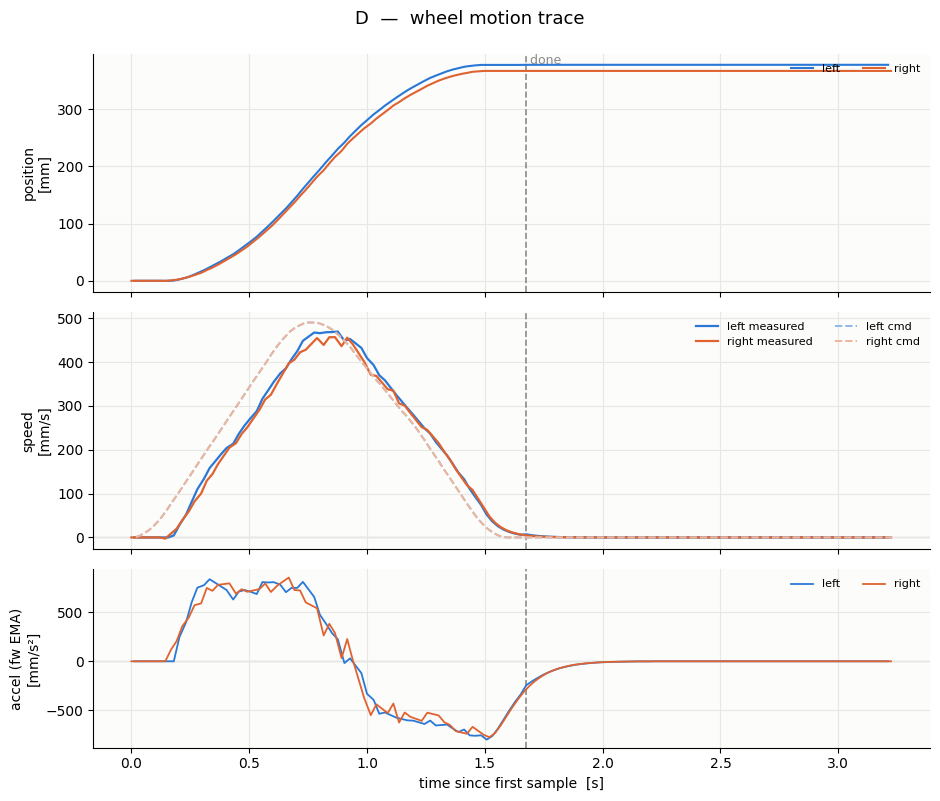

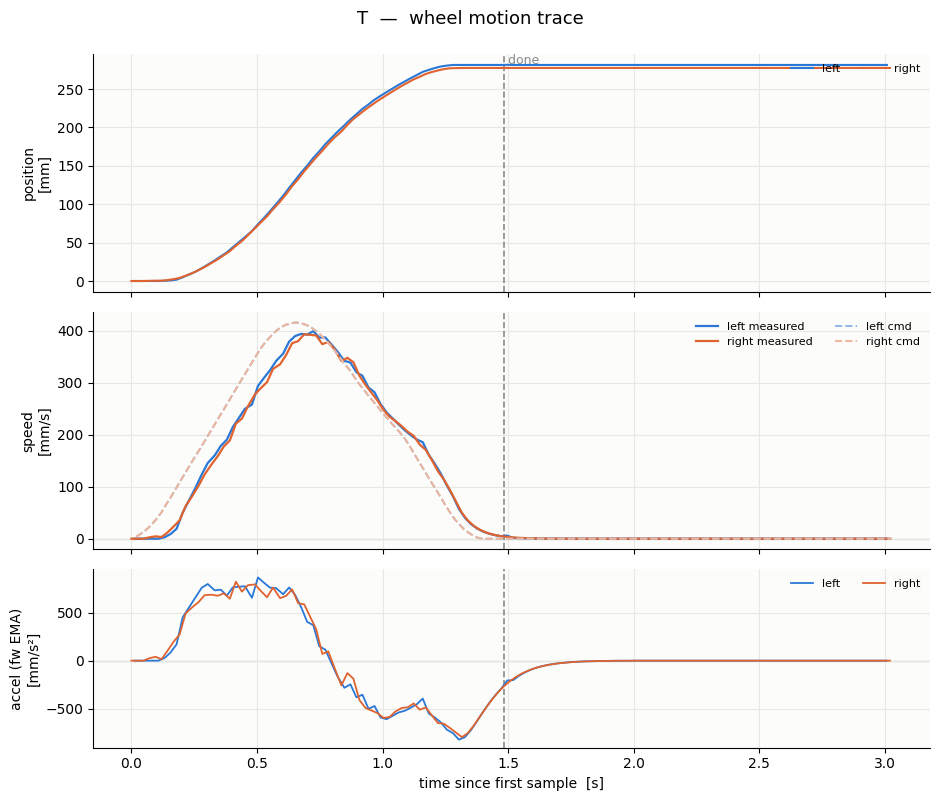

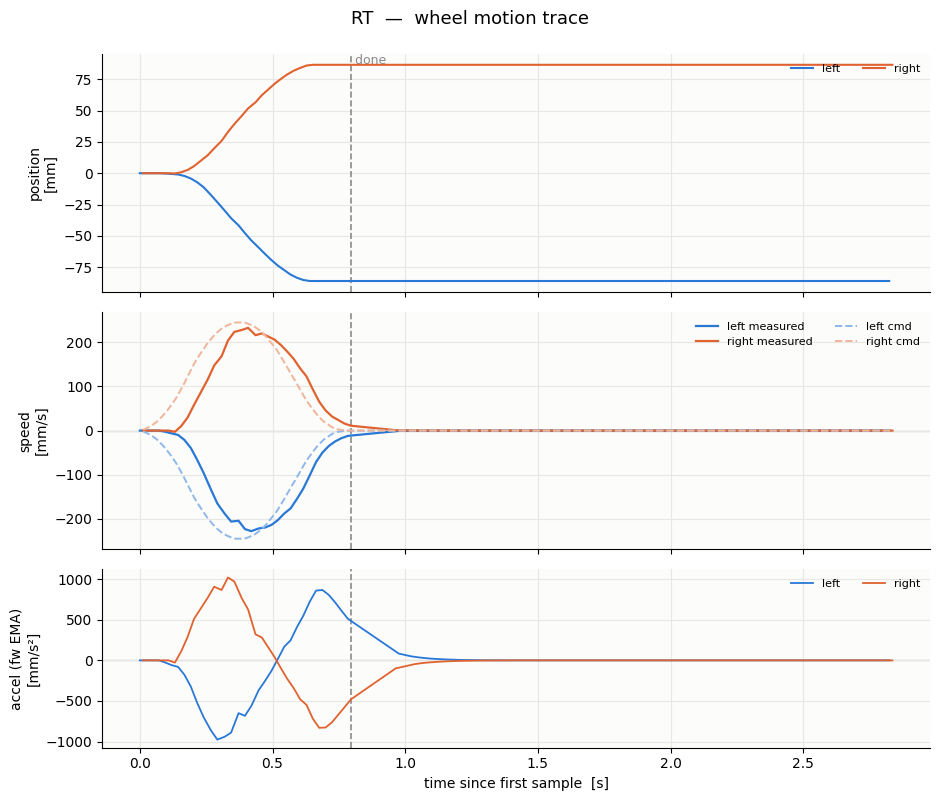

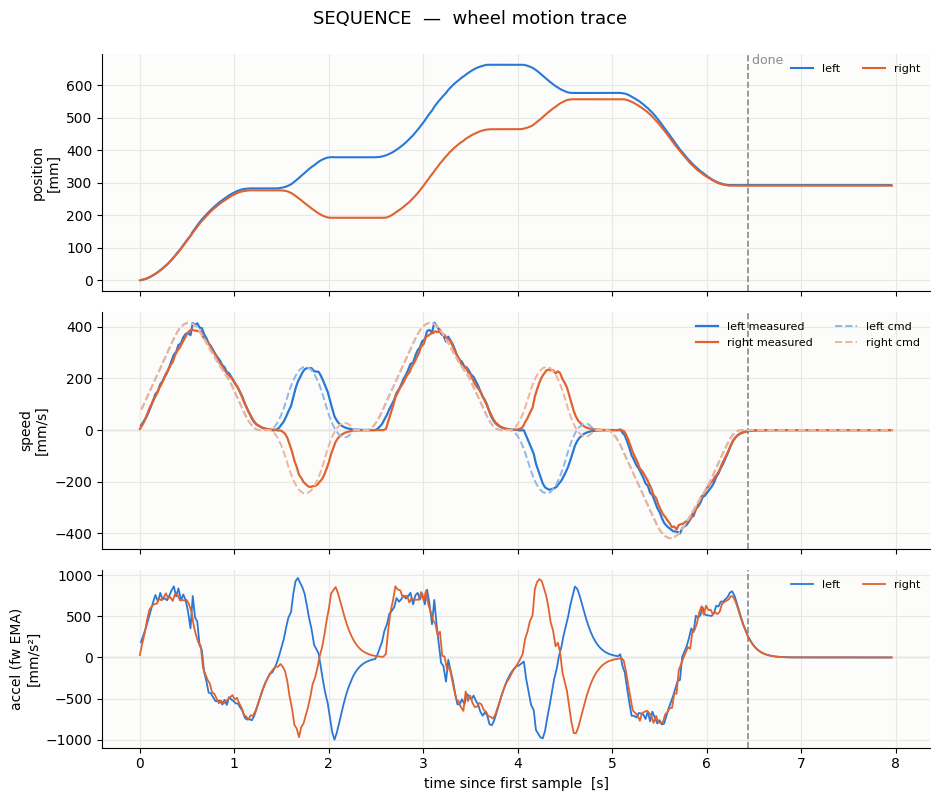

In [4]:
# --- Chart: position / speed (commanded vs measured) / acceleration -------
# One figure per run, both wheels, every channel plotted at its TRUE
# firmware time: measured channels at their wheel's `ts=` sample instants,
# the commanded setpoint at the `now=` loop-pass instant it was COMMITTED.
# Stale poll repeats are dropped, so what raggedness remains is REAL --
# not sampling aliasing, not USB-CDC delivery jitter.
import matplotlib.pyplot as plt

LEFT = "#2a78d6"    # left wheel (measured)
RIGHT = "#e0632f"   # right wheel (measured)
CMD_L = "#8fb8e8"   # left commanded (lighter, dashed)
CMD_R = "#f0b499"   # right commanded (lighter, dashed)
DONE = "#8a8a8a"    # completion marker


def plot_run(label, df, done_t):
    if df is None or df.empty:
        print(f"{label}: no data")
        return
    has_ts = "ts_l" in df.columns and (df["ts_l"] > 0).any()
    has_now = "now" in df.columns and (df["now"] > 0).any()
    ts0 = ts_origin(df) if has_ts else None

    # Completion marker on the firmware axis: the freshest wheel stamp on the
    # last active=1 row.
    done_fw = None
    act = df["active"].to_numpy()
    if has_ts and len(act) and act.max() == 1:
        row = df.iloc[np.where(act == 1)[0][-1]]
        done_fw = (max(row["ts_l"], row["ts_r"]) - ts0) / 1000.0

    def series(col, stamp_col):
        if has_ts:
            return wheel_series(df, col, stamp_col, ts0)
        return df["t"], df[col]

    fig, axes = plt.subplots(3, 1, figsize=(9.5, 8), sharex=True,
                             facecolor="white",
                             gridspec_kw={"height_ratios": [2, 2, 1.5]})
    fig.suptitle(f"{label}  —  wheel motion trace", fontsize=13, y=0.995)
    for ax in axes:
        ax.set_facecolor("#fcfcfb")
        ax.grid(True, color="#e8e7e3", lw=0.8, zorder=0)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        if done_fw is not None:
            ax.axvline(done_fw, color=DONE, ls="--", lw=1.2, zorder=2)

    ax_pos, ax_vel, ax_acc = axes

    # 1. position (per-wheel true sample times)
    ax_pos.plot(*series("pos_l", "ts_l"), color=LEFT, lw=1.5, label="left")
    ax_pos.plot(*series("pos_r", "ts_r"), color=RIGHT, lw=1.5, label="right")
    ax_pos.set_ylabel("position\n[mm]")

    # 2. speed: measured (solid, wheel sample times) + commanded (dashed,
    #    loop-pass commit times -- receive-time placement kinked the ramps)
    ax_vel.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    ax_vel.plot(*series("vel_l", "ts_l"), color=LEFT, lw=1.6, label="left measured")
    ax_vel.plot(*series("vel_r", "ts_r"), color=RIGHT, lw=1.6, label="right measured")
    if "cmd_l" in df.columns:
        cmd_stamp = "now" if has_now else ("ts_l" if has_ts else None)
        if cmd_stamp:
            ax_vel.plot(*series("cmd_l", cmd_stamp), color=CMD_L, lw=1.4, ls="--", label="left cmd")
            ax_vel.plot(*series("cmd_r", cmd_stamp), color=CMD_R, lw=1.4, ls="--", label="right cmd")
        else:
            ax_vel.plot(df["t"], df["cmd_l"], color=CMD_L, lw=1.4, ls="--", label="left cmd")
            ax_vel.plot(df["t"], df["cmd_r"], color=CMD_R, lw=1.4, ls="--", label="right cmd")
    ax_vel.set_ylabel("speed\n[mm/s]")

    # 3. acceleration -- firmware EMA, at each wheel's sample times
    ax_acc.axhline(0, color="#c9c9c9", lw=1.0, zorder=1)
    if "acc_l" in df.columns:
        ax_acc.plot(*series("acc_l", "ts_l"), color=LEFT, lw=1.3, label="left")
        ax_acc.plot(*series("acc_r", "ts_r"), color=RIGHT, lw=1.3, label="right")
    ax_acc.set_ylabel("accel (fw EMA)\n[mm/s²]")

    for ax in axes:
        ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=2)
    if done_fw is not None:
        ax_pos.text(done_fw, ax_pos.get_ylim()[1], " done",
                    color=DONE, fontsize=9, va="top")
    ax_acc.set_xlabel("time since first sample  [s]")
    fig.tight_layout()
    plt.show()


for r in RUNS:
    df, done = captures.get(r["label"], (None, None))
    plot_run(r["label"], df, done)

In [5]:
# --- Summary: net travel, terminal reverse-creep, glitches per run --------
# reverse-creep = how far each wheel travels BACKWARD (against its own net
# direction) after the completion edge -- >~1 mm is real creep, not noise.
# 094's graceful decel-to-zero should keep this near 0. glitch_* is the
# firmware's cumulative count of source-rejected corrupt encoder reads at the
# END of the run (a rising count between runs = bus noise, not motion).

def summarize(df, done_t):
    if df is None or df.empty:
        return {"frames": 0}
    out = {"frames": len(df)}
    for side in ("l", "r"):
        pos = df[f"pos_{side}"]
        out[f"travel_{side}"] = round(float(pos.iloc[-1] - pos.iloc[0]), 1)   # [mm] net
        creep = None
        if done_t is not None:
            post = df[df["t"] >= done_t]
            at = pos[df["t"] <= done_t]
            base = at.iloc[-1] if len(at) else pos.iloc[0]
            sign = 1.0 if (pos.iloc[-1] - pos.iloc[0]) >= 0 else -1.0
            if not post.empty:
                creep = round(max(0.0, -float(((post[f"pos_{side}"] - base) * sign).min())), 2)
        out[f"reverse_{side}"] = creep   # [mm]
        if f"glitch_{side}" in df.columns:
            out[f"glitch_{side}"] = int(df[f"glitch_{side}"].iloc[-1])
    return out


pd.DataFrame([{"run": r["label"], "commands": " | ".join(r["commands"]),
               **summarize(*captures.get(r["label"], (None, None)))}
              for r in RUNS])

,run,commands,frames,travel_l,reverse_l,glitch_l,travel_r,reverse_r,glitch_r
0,D,D 200 200 400,172,377.7,0.0,0,367.0,0.0,0
1,T,T 200 200 1500,168,281.3,0.0,0,277.4,0.0,0
2,RT,RT 9000,122,-86.0,0.0,0,86.5,0.0,0
3,SEQUENCE,MOVE 300 0 0 | MOVE 0 0 -9000 | MOVE 300 0 0 |...,427,292.0,0.0,0,291.1,0.0,0
